In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_parquet('Salary_Data (2).parquet')
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


## STEP:1 SANITY CLEAN

In [ ]:
df.shape

(6704, 6)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   object 
 2   Education Level      6701 non-null   object 
 3   Job Title            6702 non-null   object 
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), object(3)
memory usage: 314.4+ KB


In [ ]:
df.isna().sum()

,0
Age,2
Gender,2
Education Level,3
Job Title,2
Years of Experience,3
Salary,5


## Find a Duplicated Values

In [ ]:
df.duplicated().sum()

np.int64(4912)

## Find a Garbage Values

In [ ]:
for col in df.select_dtypes(include='number').columns:
  print(df.value_counts())
  print("*****"*10)

Age   Gender  Education Level    Job Title                  Years of Experience  Salary  
24.0  Female  High School        Receptionist               0.0                  25000.0     45
32.0  Male    Bachelor's Degree  Product Manager            7.0                  120000.0    45
27.0  Male    Bachelor's Degree  Software Engineer          3.0                  80000.0     45
32.0  Male    Bachelor's         Software Engineer          8.0                  190000.0    39
33.0  Female  Master's           Product Manager            11.0                 198000.0    38
                                                                                             ..
23.0  Male    High School        Sales Executive            1.0                  35000.0      1
              PhD                Software Engineer Manager  1.0                  579.0        1
54.0  Male    PhD                Software Engineer Manager  28.0                 182013.0     1
23.0  Male    Bachelor's         Data Analyst 

## Explorative Data Analysis (EDA)

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,6702.0,33.620859,7.614633,21.0,28.0,32.0,38.0,62.0
Years of Experience,6701.0,8.094687,6.059003,0.0,3.0,7.0,12.0,34.0
Salary,6699.0,115326.964771,52786.183911,350.0,70000.0,115000.0,160000.0,250000.0


In [ ]:
df.describe(include='object')

,Gender,Education Level,Job Title
count,6702,6701,6702
unique,3,7,193
top,Male,Bachelor's Degree,Software Engineer
freq,3674,2267,518


In [ ]:
df.select_dtypes(include='number').columns

Index(['Age', 'Years of Experience', 'Salary'], dtype='object')

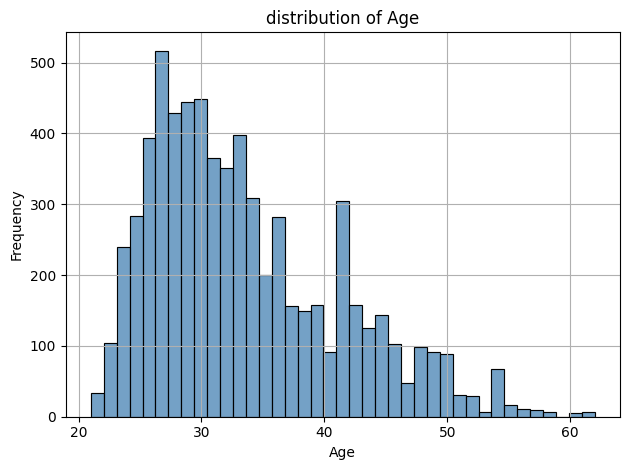

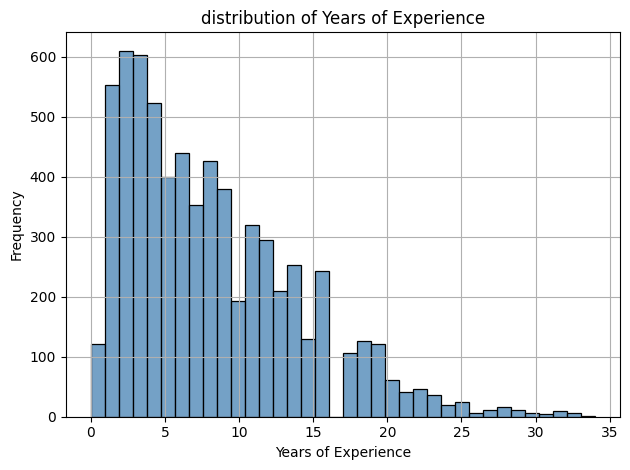

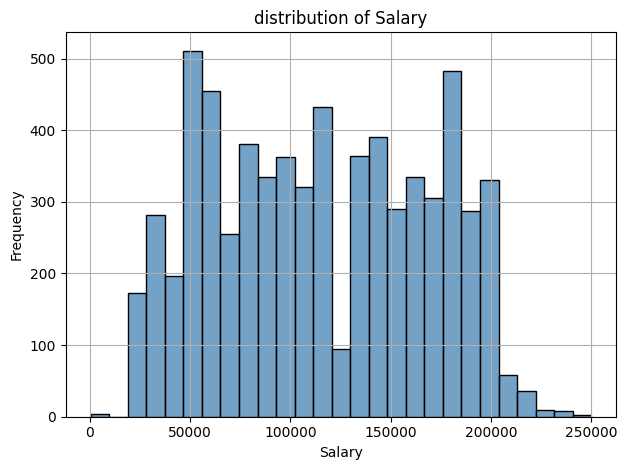

In [ ]:
for col in df.select_dtypes(include='number').columns:
  sns.histplot(df[col],color='steelblue')
  plt.grid()
  plt.ylabel("Frequency")
  plt.title(f"distribution of {col}")
  plt.tight_layout()
  plt.show()

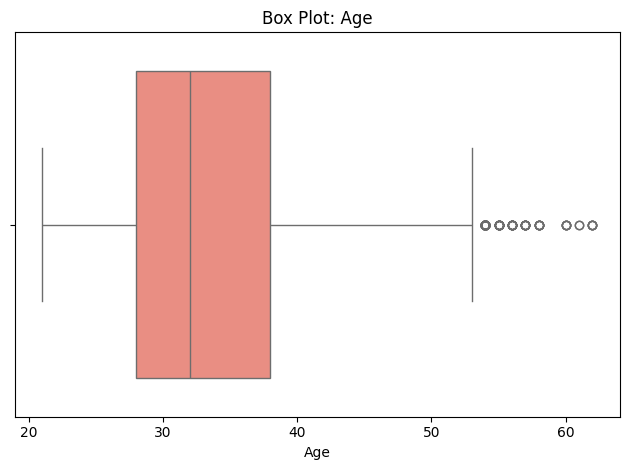

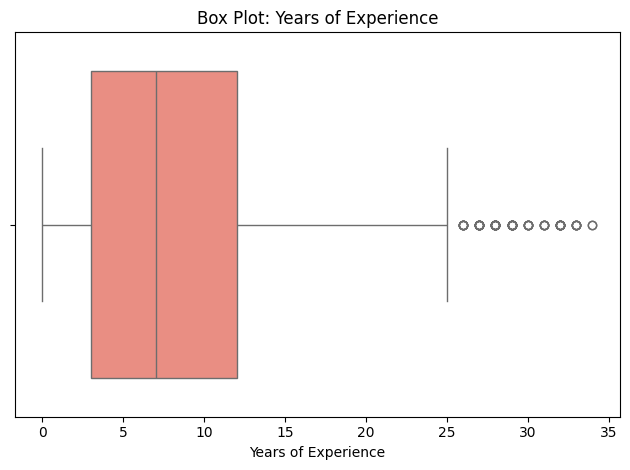

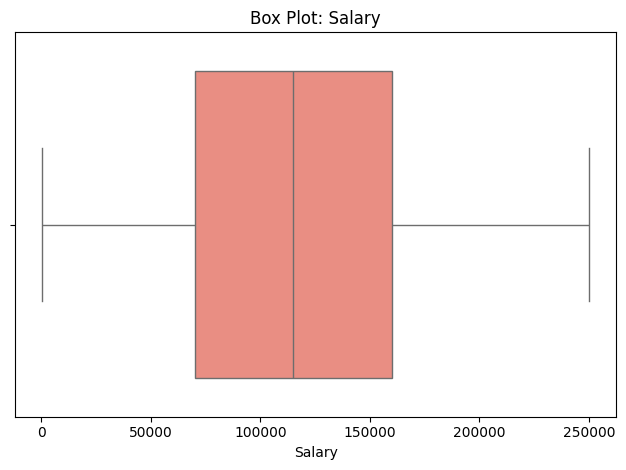

In [ ]:
for col in df.select_dtypes(include='number').columns:
    sns.boxplot(data=df, x=col, color='salmon')
    plt.title(f'Box Plot: {col}')
    plt.tight_layout()
    plt.show()

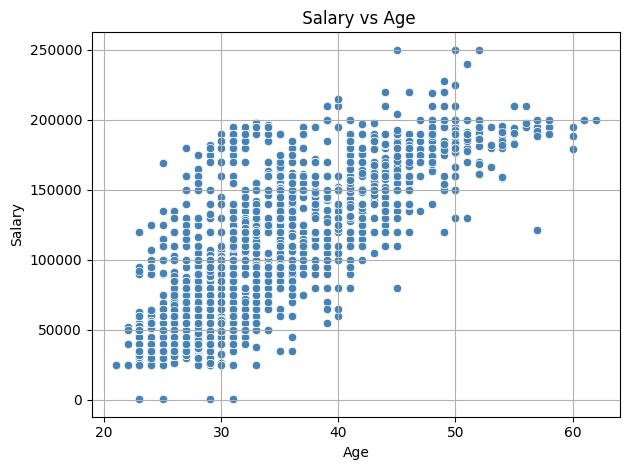

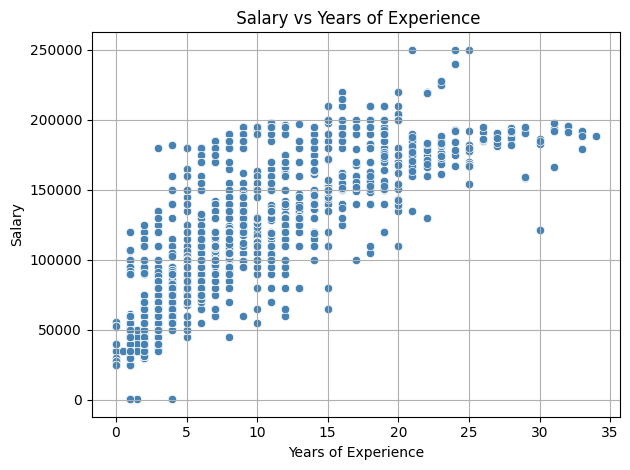

In [ ]:
for col in df.select_dtypes(include='number').columns:
  if col == 'Salary':
    continue
  sns.scatterplot(data=df,x=col,y='Salary',color='steelblue')
  plt.grid()
  plt.title(f" Salary vs {col}")
  plt.tight_layout()
  plt.show()

## Heat Map

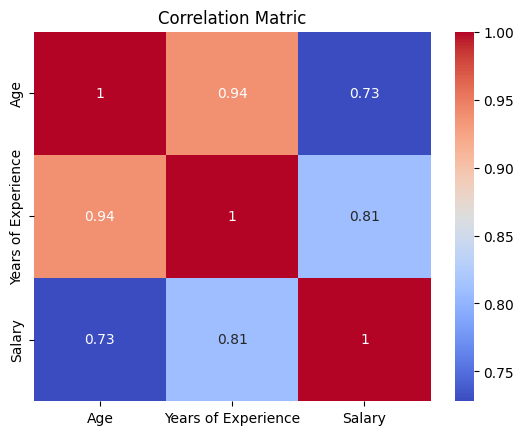

In [ ]:
corr_mat = df.select_dtypes(include='number').corr()
sns.heatmap(corr_mat,annot=True,cmap='coolwarm')
plt.title("Correlation Matric")
plt.show()

## Missing Values Treatment

In [ ]:
for col in df.select_dtypes(include='number').columns:
  df[col].fillna(df[col].median(),inplace=True)
for col in df.select_dtypes(include='object').columns:
  df[col].fillna(df[col].mode()[0],inplace=True)

In [ ]:
df.isna().sum()

,0
Age,0
Gender,0
Education Level,0
Job Title,0
Years of Experience,0
Salary,0


## Duplicate Value Treatment

In [ ]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

## Outlier Treatment

In [ ]:
def whisker(col):
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3-q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  return lower_bound,upper_bound

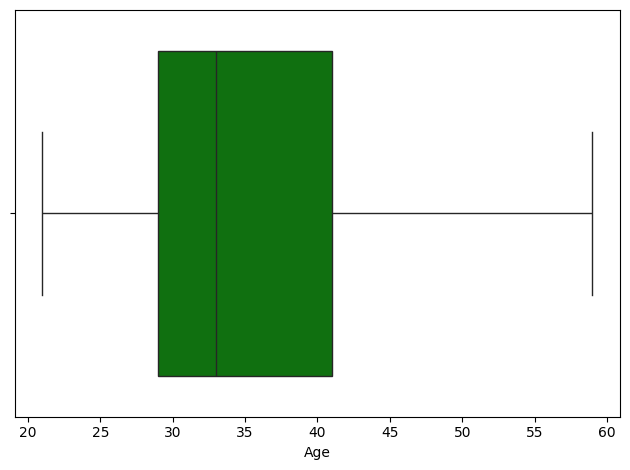

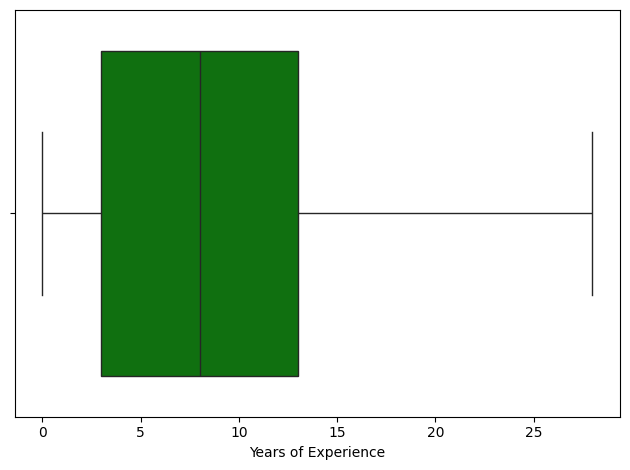

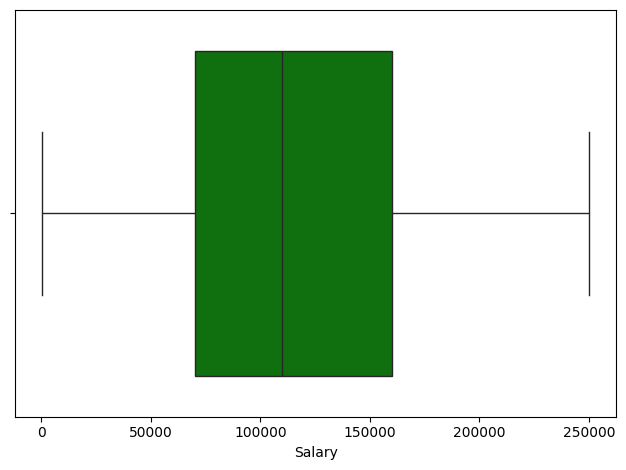

In [ ]:
for col  in df.select_dtypes(include='number').columns:
  lower_bound,upper_bound = whisker(col)
  df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
  df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
  sns.boxplot(data=df,x=col,color='green')
  plt.tight_layout()
  plt.show()

## Garbage Treatment

In [ ]:
garbage_values = ['?', 'NA', 'unknown', 'Unknown', '-', 'N/A', 'na']
for col in df.select_dtypes(include='object').columns:
  df[col] = df[col].str.strip()
  df[col] = df[col].str.capitalize()
  df[col] = df[col].replace(garbage_values,np.nan)

## Label encoding

In [ ]:
df = pd.get_dummies(
    df,
    columns=['Gender', 'Education Level', 'Job Title'],
    drop_first=True,
    dtype=int
)

In [ ]:
df

,Age,Years of Experience,Salary,Gender_Male,Gender_Other,Education Level_Bachelor's degree,Education Level_High school,Education Level_Master's,Education Level_Master's degree,Education Level_Phd,...,Job Title_Supply chain manager,Job Title_Technical recruiter,Job Title_Technical support specialist,Job Title_Technical writer,Job Title_Training specialist,Job Title_Ux designer,Job Title_Ux researcher,Job Title_Vp of finance,Job Title_Vp of operations,Job Title_Web developer
0,32.0,5.0,90000.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,28.0,3.0,65000.0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,45.0,15.0,150000.0,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,36.0,7.0,60000.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,52.0,20.0,200000.0,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6623,43.0,15.0,150000.0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
6624,27.0,2.0,40000.0,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6625,33.0,8.0,80000.0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6628,37.0,7.0,90000.0,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
x = df.drop('Salary', axis=1)
y = df['Salary']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)
le = LinearRegression()
le.fit(x_train,y_train)
y_pred = le.predict(x_test)
score = r2_score(y_test, y_pred)
print("R2_score: ",round(score,2))
import numpy as np
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(rmse)
print(rmse/np.mean(df['Salary'])*100)# it is a relative error estimation around 20% That is: decent, usable for learning ,not highly precise

R2_score:  0.83
21622.904786955314
19.1046528031263


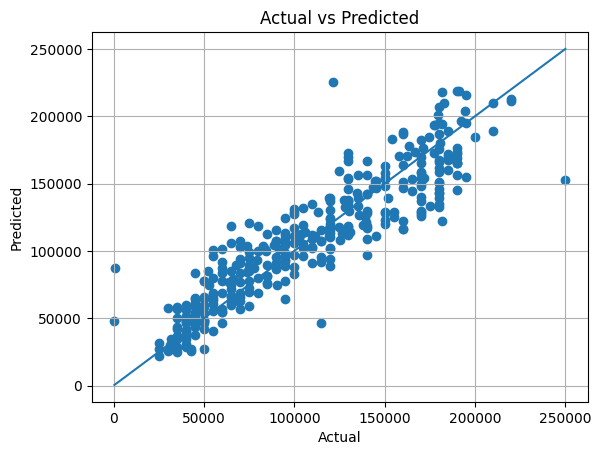

In [ ]:
plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.grid(True)
plt.show()

In [ ]:

sample = pd.DataFrame(
    0,
    index=[0],
    columns=x.columns
)
sample['Age']=32
sample['Gender_Male'] = 1
sample['Years of Experience'] = 5

sample['Education Level_High school'] = 0

sample['Job Title_Supply chain manager'] = 0
prediction = le.predict(sample)

print("Predicted Salary:", round(prediction[0]))

Predicted Salary: 75000


In [ ]:
df

,Age,Years of Experience,Salary,Gender_Male,Gender_Other,Education Level_Bachelor's degree,Education Level_High school,Education Level_Master's,Education Level_Master's degree,Education Level_Phd,...,Job Title_Supply chain manager,Job Title_Technical recruiter,Job Title_Technical support specialist,Job Title_Technical writer,Job Title_Training specialist,Job Title_Ux designer,Job Title_Ux researcher,Job Title_Vp of finance,Job Title_Vp of operations,Job Title_Web developer
0,32.0,5.0,90000.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,28.0,3.0,65000.0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,45.0,15.0,150000.0,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,36.0,7.0,60000.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,52.0,20.0,200000.0,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6623,43.0,15.0,150000.0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
6624,27.0,2.0,40000.0,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6625,33.0,8.0,80000.0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6628,37.0,7.0,90000.0,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## ASSUMPTION-1: LINEARITY CHECK

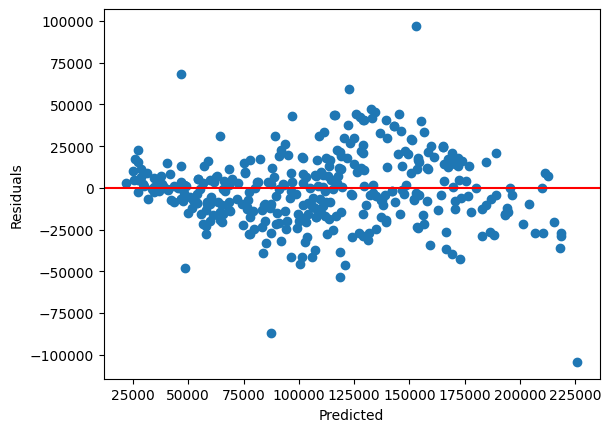

In [ ]:
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")

plt.show()

## ASSUMPTION:2 NORMALITY CHECK

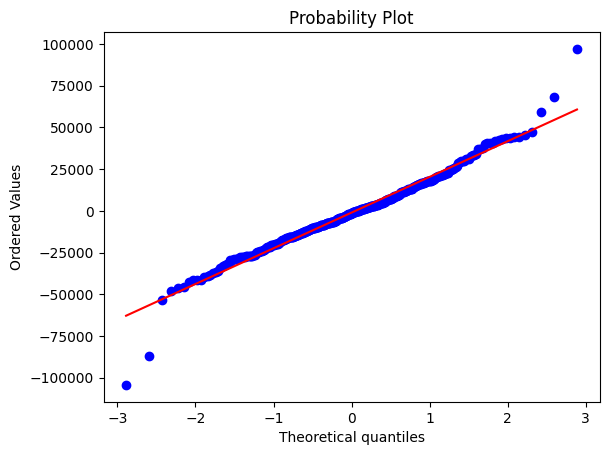

In [ ]:
import scipy.stats as stats
stats.probplot(residuals,dist='norm',plot=plt)
plt.show()

## ASSUMPTION 3 — Homoscedasticity


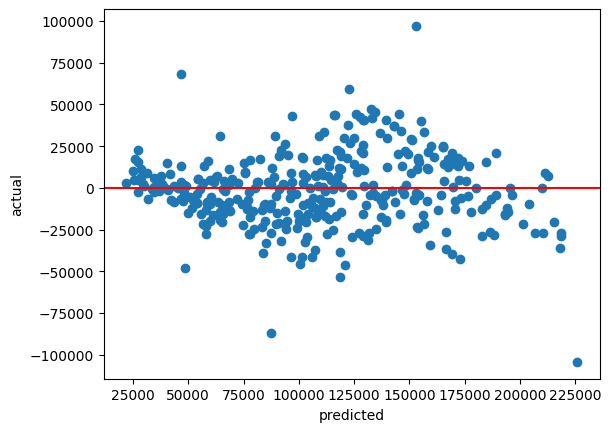

In [ ]:
plt.scatter(y_pred,residuals)
plt.axhline(y=0,color='red')
plt.xlabel("predicted")
plt.ylabel('actual')
plt.show()

## ASSUMPTION 4 — Independence of Errors

In [ ]:
from statsmodels.stats.stattools import durbin_watson
dw = durbin_watson(residuals)
print("durbin_watson value: ",dw)

durbin_watson value:  1.97388978774103


## ASSUMPTION 5 MULTICOLLINEARITY

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
X = df.drop('Salary',axis=1)
X = add_constant(X)
vif_data = pd.DataFrame()
vif_data['features'] = X.columns
vif_data['VIF'] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]
display(vif_data)

,features,VIF
0,const,1915.498176
1,Age,11.253900
2,Years of Experience,11.412887
3,Gender_Male,1.264241
4,Gender_Other,1.138648
...,...,...
196,Job Title_Ux designer,2.025218
197,Job Title_Ux researcher,2.025543
198,Job Title_Vp of finance,2.027365
199,Job Title_Vp of operations,2.027365


## Regulazations

In [ ]:
from sklearn.linear_model import Lasso,Ridge
test_score = le.score(x_test,y_test)
train_score = le.score(x_train,y_train)
print("test_score: ",test_score)
print("train_score: ",train_score)


test_score:  0.8256128377511975
train_score:  0.8792227786529707


## NOTE:
The training score (0.876) and testing score (0.854) are close to each other, with only a small difference of about 2.2%. This indicates that the model generalizes well to unseen data and does not exhibit significant overfitting. Therefore, applying regularization techniques such as L1 (Lasso) or L2 (Ridge) may not be strictly necessary for this model at the current stage.
``